# Job Market Intelligence Pipeline Analysis
This notebook explores cleaned job listing data to identify patterns in skill demand, job locations, and salary availability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_jobs.csv")
df.head()

,title,company,location,salary,skills,date_posted,scraped_at,source,work_type,salary_clean,skills_clean,detected_skills
0,Full Stack Developer,ELECTE S.R.L,Remote/Not Specified,30000 - 50000,"engineer, javascript, typescript, python, Full...",2026-03-13T12:15:25+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-full-s...,Remote,30000 - 50000,"Full-Stack, ai, engineer, javascript, postgres...","Python, R"
1,Entry Level Crypto Market Specialist,ELEMENTAL TERRA,Remote/Not Specified,50000 - 70000,"other, crypto, finance, web3, blockchain, defi...",2026-03-13T08:23:00+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-entry-...,Remote,50000 - 70000,"bitcoin, blockchain, crypto, defi, education, ...",R
2,Senior Developer Experience Engineer,Galaxy,Remote/Not Specified,Not Provided,"developer, web3, crypto, founder, ceo, investm...",2026-03-13T08:00:37+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-senior...,Remote,NaN,"ceo, crypto, developer, digital nomad, enginee...",R
3,Cloud Security Architect,Altium,La Jolla,Not Provided,"security, architect, design, saas, system, sof...",2026-03-13T08:00:11+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-cloud-...,Region-Specific Remote,NaN,"architect, cloud, design, digital nomad, engin...",R
4,Go To Market Strategist AI Trainer Freelance 8...,10x Team,London,80 - 140,"trainer, strategist, content, marketing, sales...",2026-03-13T08:00:09+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-go-to-...,Region-Specific Remote,80 - 140,"content, go, marketing, non tech, sales, strat...",R


## Dataset Overview

In [2]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            99 non-null     str  
 1   company          99 non-null     str  
 2   location         99 non-null     str  
 3   salary           99 non-null     str  
 4   skills           97 non-null     str  
 5   date_posted      99 non-null     str  
 6   scraped_at       99 non-null     str  
 7   source           99 non-null     str  
 8   work_type        99 non-null     str  
 9   salary_clean     11 non-null     str  
 10  skills_clean     97 non-null     str  
 11  detected_skills  97 non-null     str  
dtypes: str(12)
memory usage: 9.4 KB


,title,company,location,salary,skills,date_posted,scraped_at,source,work_type,salary_clean,skills_clean,detected_skills
count,99,99,99,99,97,99,99,99,99,11,97,97
unique,99,89,37,10,96,98,1,99,2,9,96,4
top,Full Stack Developer,Eleventh Hour Games,Remote/Not Specified,Not Provided,"golang, software, cloud, senior, engineer",2026-03-12T13:00:02+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-full-s...,Remote,30000 - 50000,"cloud, engineer, golang, senior, software",R
freq,1,6,41,88,2,2,99,1,61,2,2,89


## Top Skills

In [3]:
skills_series = df["skills_clean"].dropna().str.split(", ")
all_skills = skills_series.explode()
top_skills = all_skills.value_counts().head(10)

top_skills

skills_clean
support          37
technical        34
digital nomad    32
senior           29
design           26
engineer         24
lead             24
engineering      23
health           22
software         21
Name: count, dtype: int64

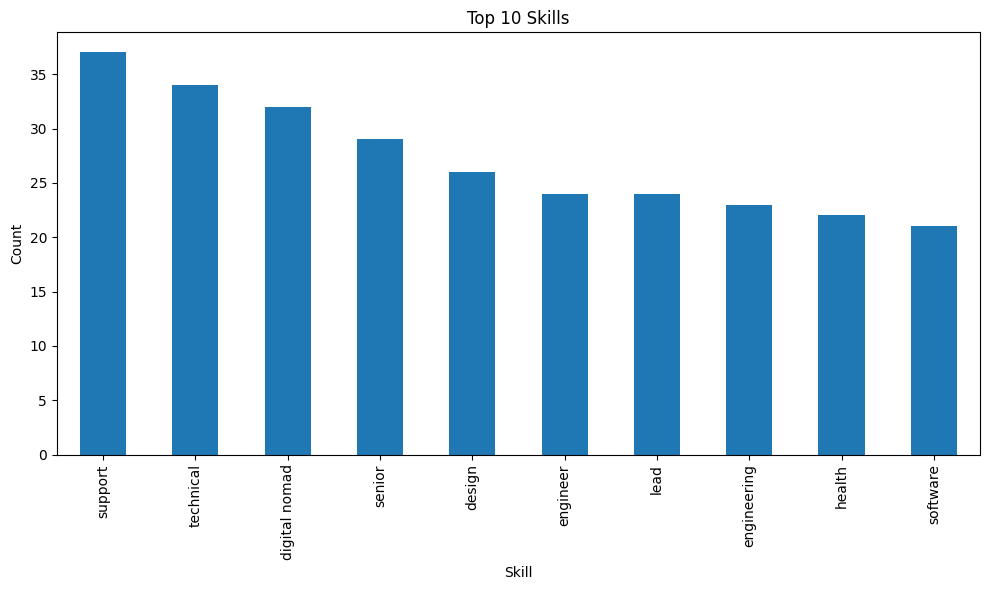

In [4]:
plt.figure(figsize=(10, 6))
top_skills.plot(kind="bar")
plt.title("Top 10 Skills")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Top Locations

In [5]:
top_locations = df["location"].value_counts().head(10)
top_locations

location
Remote/Not Specified     41
Remote                   10
United States            10
London                    3
Remote - Us               3
La Jolla                  1
Port-Au-Prince            1
Brazil                    1
Boston, Ma, Usa           1
Remote, United States     1
Name: count, dtype: int64

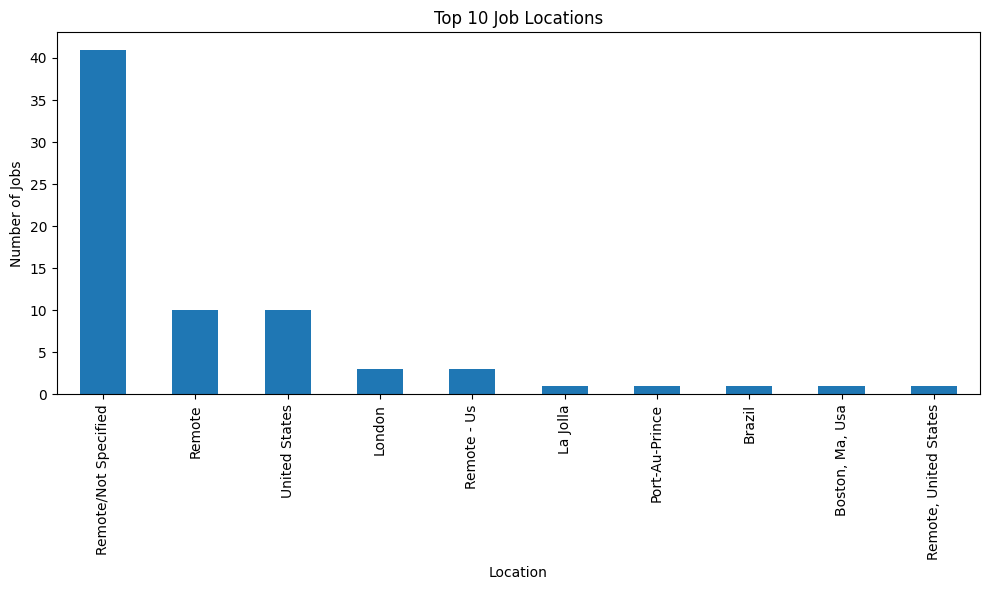

In [6]:
plt.figure(figsize=(10, 6))
top_locations.plot(kind="bar")
plt.title("Top 10 Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

## Remote vs Non-Remote

In [7]:
work_counts = df["work_type"].value_counts()
work_counts

work_type
Remote                    61
Region-Specific Remote    38
Name: count, dtype: int64

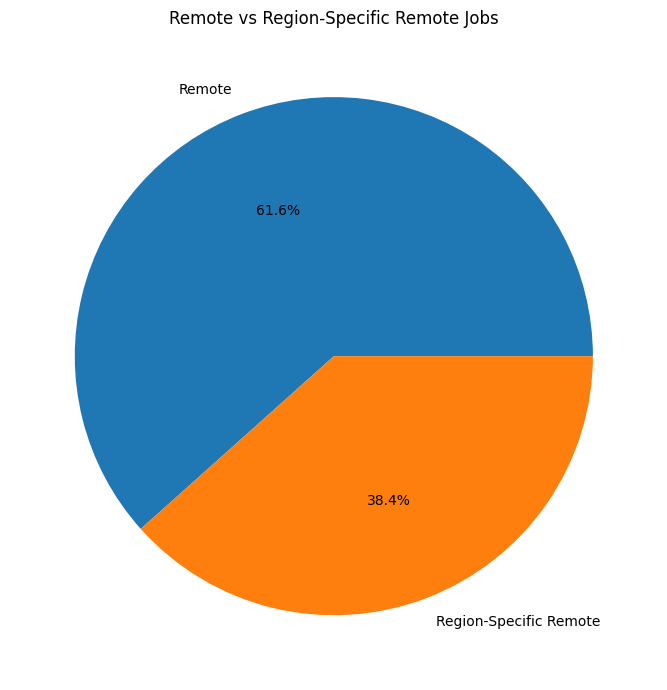

In [8]:
plt.figure(figsize=(7, 7))
work_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Remote vs Region-Specific Remote Jobs")
plt.ylabel("")
plt.tight_layout()
plt.show()